# Validasi Autodiff FFNN

Notebook ini membuktikan bahwa implementasi **autodiff** sudah benar dengan:
1. Membandingkan gradien manual (FFNN numpy) vs autodiff --> selisih sgt kecil
2. Menunjukkan training sederhana berjalan (loss turun).

In [13]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))

from ffnn import FFNN
from autodiff_ffnn import AutodiffFFNN

## 1. Bandingkan Gradien (Manual vs Autodiff)

In [14]:
# Small deterministic example
layer_sizes = [3, 2, 2]
activations = ['tanh', 'linear']

# Fixed weights/biases for reproducibility
W1 = np.array([[0.1, -0.2], [0.3, 0.4], [-0.5, 0.2]])
b1 = np.array([[0.01, -0.02]])
W2 = np.array([[0.2, -0.1], [0.05, 0.3]])
b2 = np.array([[0.0, 0.1]])

X = np.array([[0.5, -1.0, 2.0]])
y = np.array([[0.2, -0.1]])

In [15]:
# Manual FFNN
ffnn = FFNN(layer_sizes, activations, weight_initial='normal')
ffnn.weights = [W1.copy(), W2.copy()]
ffnn.biases = [b1.copy(), b2.copy()]
_ = ffnn.forward(X)
ffnn.backward(y_true=y, loss_type='mse')
grad_w_manual = ffnn.grad_weights
grad_b_manual = ffnn.grad_biases

# Autodiff FFNN
ad = AutodiffFFNN(layer_sizes, activations)
ad.set_params([W1, W2], [b1[0], b2[0]])
pred = ad.forward(X[0].tolist())
loss = ad.mse_loss(y[0].tolist(), pred)
ad.zero_grad()
loss.backward()
grad_w_auto, grad_b_auto = ad.get_grads()

In [16]:
# Compare gradients (show absolute diff)
print('W1 diff:', np.abs(grad_w_manual[0] - np.array(grad_w_auto[0])))
print('b1 diff:', np.abs(grad_b_manual[0] - np.array(grad_b_auto[0])))
print('W2 diff:', np.abs(grad_w_manual[1] - np.array(grad_w_auto[1])))
print('b2 diff:', np.abs(grad_b_manual[1] - np.array(grad_b_auto[1])))

W1 diff: [[3.46944695e-18 6.93889390e-18]
 [6.93889390e-18 1.38777878e-17]
 [1.38777878e-17 2.77555756e-17]]
b1 diff: [[6.93889390e-18 1.38777878e-17]]
W2 diff: [[5.55111512e-17 8.32667268e-17]
 [0.00000000e+00 1.04083409e-17]]
b2 diff: [[0.00000000e+00 5.55111512e-17]]


## 2. Training Sederhana (Autodiff)

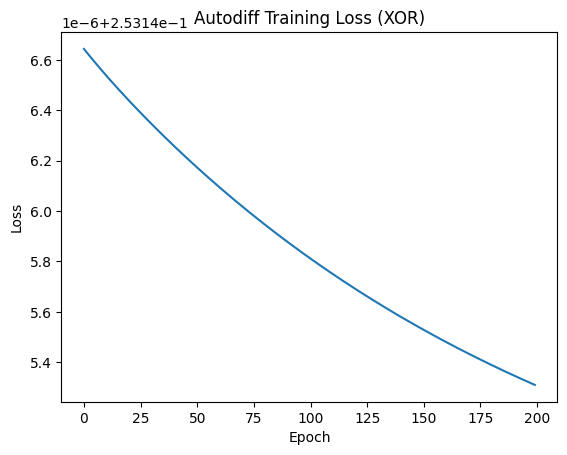

In [17]:
# XOR dataset
X_xor = [
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0],
]
y_xor = [
    [0.0],
    [1.0],
    [1.0],
    [0.0],
]

model = AutodiffFFNN([2, 2, 1], ['tanh', 'sigmoid'])
lr = 0.1
epochs = 200
losses = []

for epoch in range(epochs):
    total_loss = 0.0
    for xi, yi in zip(X_xor, y_xor):
        pred = model.forward(xi)
        loss = model.mse_loss(yi, pred)
        total_loss += loss.data

        model.zero_grad()
        loss.backward()
        model.sgd_step(lr)

    losses.append(total_loss / len(X_xor))

plt.plot(losses)
plt.title('Autodiff Training Loss (XOR)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [18]:
# Final predictions
for xi, yi in zip(X_xor, y_xor):
    pred = model.forward(xi)[0].data
    print(f'x={xi} y={yi[0]} pred={pred:.4f}')

x=[0.0, 0.0] y=0.0 pred=0.4999
x=[0.0, 1.0] y=1.0 pred=0.5000
x=[1.0, 0.0] y=1.0 pred=0.5000
x=[1.0, 1.0] y=0.0 pred=0.5000
